PREGNANCY DETECTION USING ANN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
%matplotlib inline

In [2]:
df=pd.read_csv("babies.csv")

In [3]:
df

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0
...,...,...,...,...,...,...,...,...
1231,1232,113,275.0,1,27.0,60.0,100.0,0.0
1232,1233,128,265.0,0,24.0,67.0,120.0,0.0
1233,1234,130,291.0,0,30.0,65.0,150.0,1.0
1234,1235,125,281.0,1,21.0,65.0,110.0,0.0


In [4]:
df.head()

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0


In [5]:
df.tail()

,case,bwt,gestation,parity,age,height,weight,smoke
1231,1232,113,275.0,1,27.0,60.0,100.0,0.0
1232,1233,128,265.0,0,24.0,67.0,120.0,0.0
1233,1234,130,291.0,0,30.0,65.0,150.0,1.0
1234,1235,125,281.0,1,21.0,65.0,110.0,0.0
1235,1236,117,297.0,0,38.0,65.0,129.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   case       1236 non-null   int64  
 1   bwt        1236 non-null   int64  
 2   gestation  1223 non-null   float64
 3   parity     1236 non-null   int64  
 4   age        1234 non-null   float64
 5   height     1214 non-null   float64
 6   weight     1200 non-null   float64
 7   smoke      1226 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 77.4 KB


In [7]:
df.describe()

,case,bwt,gestation,parity,age,height,weight,smoke
count,1236.000000,1236.000000,1223.000000,1236.000000,1234.000000,1214.000000,1200.000000,1226.000000
mean,618.500000,119.576861,279.338512,0.254854,27.255267,64.047776,128.625833,0.394780
std,356.946775,18.236452,16.027693,0.435956,5.781405,2.533409,20.971862,0.489003
min,1.000000,55.000000,148.000000,0.000000,15.000000,53.000000,87.000000,0.000000
25%,309.750000,108.750000,272.000000,0.000000,23.000000,62.000000,114.750000,0.000000
50%,618.500000,120.000000,280.000000,0.000000,26.000000,64.000000,125.000000,0.000000
75%,927.250000,131.000000,288.000000,1.000000,31.000000,66.000000,139.000000,1.000000
max,1236.000000,176.000000,353.000000,1.000000,45.000000,72.000000,250.000000,1.000000


In [8]:
df.isnull().sum()

case          0
bwt           0
gestation    13
parity        0
age           2
height       22
weight       36
smoke        10
dtype: int64

In [9]:
df['gestation'].fillna(df['gestation'].median(), inplace=True)
df['age'].fillna(df['age'].median(), inplace=True)
df['height'].fillna(df['height'].median(), inplace=True)
df['weight'].fillna(df['weight'].median(), inplace=True)
df['smoke'].fillna(df['smoke'].mode()[0], inplace=True)  # if smoke is categorical (0/1)

C:\Users\Vennela\AppData\Local\Temp\ipykernel_2588\453221188.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gestation'].fillna(df['gestation'].median(), inplace=True)
C:\Users\Vennela\AppData\Local\Temp\ipykernel_2588\453221188.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [10]:
df.dropna(inplace=True)

In [11]:
df.isnull().sum()

case         0
bwt          0
gestation    0
parity       0
age          0
height       0
weight       0
smoke        0
dtype: int64

In [12]:
df.sample(5)

,case,bwt,gestation,parity,age,height,weight,smoke
157,158,133,287.0,0,24.0,60.0,104.0,1.0
254,255,130,274.0,0,26.0,64.0,185.0,0.0
968,969,118,278.0,1,19.0,62.0,126.0,0.0
1009,1010,108,270.0,0,29.0,67.0,124.0,1.0
613,614,119,285.0,1,26.0,62.0,108.0,0.0


In [13]:
df.shape

(1236, 8)

In [14]:
df.columns

Index(['case', 'bwt', 'gestation', 'parity', 'age', 'height', 'weight',
       'smoke'],
      dtype='object')

In [15]:
X=df.drop('smoke',axis=1).values
y=df['smoke'].values

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=30)

In [17]:
X_train

array([[ 108.,  126.,  273., ...,   22.,   65.,  150.],
       [1027.,  143.,  313., ...,   20.,   68.,  150.],
       [ 472.,  101.,  278., ...,   27.,   61.,   99.],
       ...,
       [ 501.,   69.,  232., ...,   31.,   59.,  103.],
       [ 942.,  105.,  280., ...,   22.,   63.,  116.],
       [ 422.,  119.,  286., ...,   20.,   67.,  130.]], shape=(988, 7))

In [18]:
X_test

array([[1104.,  128.,  267., ...,   37.,   61.,  142.],
       [ 250.,  142.,  274., ...,   24.,   63.,  125.],
       [  57.,  124.,  278., ...,   26.,   70.,  145.],
       ...,
       [ 339.,  111.,  270., ...,   22.,   59.,  103.],
       [1101.,  129.,  278., ...,   26.,   67.,  146.],
       [  68.,  137.,  274., ...,   26.,   69.,  137.]], shape=(248, 7))

In [19]:
y_test

array([0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0.,
       0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
       0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1.,
       0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 0.,
       1., 1., 0., 0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0.,
       0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 1.,
       1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0.,
       0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0.,
       0., 1., 0., 0., 1.

In [20]:
y_train

array([0., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0.,
       0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0., 1.,
       1., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0.,
       1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0.,
       0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
       1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 0.,
       0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1.,
       0., 1., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0.,
       0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0.,
       1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 0., 0.,
       1., 1., 0., 1., 0.

In [21]:
y_train.shape

(988,)

In [22]:
X_train.shape

(988, 7)

In [23]:
# scaling
from sklearn.preprocessing import StandardScaler,LabelEncoder
# assuming case is categorical column
input_data=pd.DataFrame({
    'case':['A','B','A','C'],
    'feature1':[1.2,3.4,5.6,7.8],
    'feature2':[10,20,30,40]
})
le=LabelEncoder()
input_data['case']=le.fit_transform(input_data['case'])
scaler=StandardScaler()
input_scaled=scaler.fit_transform(input_data.select_dtypes(include=[float,int]))

In [24]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [25]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

,0,1,2,3,4,5,6
0,-1.427169,0.358072,-0.408008,-0.588259,-0.907684,0.375200,1.042446
1,1.132595,1.302954,2.169848,-0.588259,-1.255547,1.586628,1.042446
2,-0.413291,-1.031460,-0.085776,-0.588259,-0.038026,-1.240039,-1.398729
3,-1.273973,0.302490,-1.116919,-0.588259,1.527359,0.779009,2.957093
4,-0.299090,0.635978,-1.052473,-0.588259,0.309838,-0.028610,2.478431


In [26]:
joblib.dump(scaler,"scaler.pk1")

['scaler.pk1']

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,InputLayer,Dropout

In [28]:
model=Sequential([Dense(16,activation='relu',input_shape=(X_train.shape[1],)),
                  Dense(8,activation='relu'),
                  Dense(1,activation='sigmoid')
                 ])

C:\Users\Vennela\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy']
             )

In [30]:
model.fit(x=X_train,y=
          y_train,epochs=50,validation_data=(X_test,y_test))

Epoch 1/50


C:\Users\Vennela\anaconda3\Lib\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5435 - loss: 0.0000e+00 - val_accuracy: 0.5968 - val_loss: 0.0000e+00
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5688 - loss: 0.0000e+00 - val_accuracy: 0.6371 - val_loss: 0.0000e+00
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5911 - loss: 0.0000e+00 - val_accuracy: 0.6411 - val_loss: 0.0000e+00
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5982 - loss: 0.0000e+00 - val_accuracy: 0.6492 - val_loss: 0.0000e+00
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5982 - loss: 0.0000e+00 - val_accuracy: 0.6492 - val_loss: 0.0000e+00
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5982 - loss: 0.0000e+00 - val_accuracy: 0.6492 - val_loss: 0.0000e+00
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5982 - loss: 0.0000e+00 - val_accuracy: 0.6492 - val_loss: 0.0000e+00
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5982 - l

In [31]:
model_loss=pd.DataFrame(model.history.history)

<Axes: >

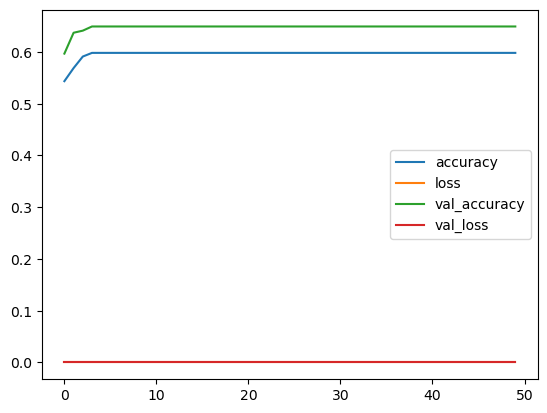

In [32]:
model_loss.plot()

In [33]:
# early stopping
model=Sequential([Dense(16,activation='relu',input_shape=(X_train.shape[1],)),
                  Dense(8,activation='relu'),
                  Dense(1,activation='sigmoid')
                 ])

C:\Users\Vennela\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
from tensorflow.keras.callbacks import EarlyStopping

In [35]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=50)

In [36]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy']
             )

In [37]:
history=model.fit(x=X_train,
          y=y_train,
          epochs=50,
          validation_data=(X_test, y_test),
          callbacks=[early_stop]
          )

Epoch 1/50


C:\Users\Vennela\anaconda3\Lib\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5547 - loss: 0.0000e+00 - val_accuracy: 0.6210 - val_loss: 0.0000e+00
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5951 - loss: 0.0000e+00 - val_accuracy: 0.6492 - val_loss: 0.0000e+00
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5982 - loss: 0.0000e+00 - val_accuracy: 0.6492 - val_loss: 0.0000e+00
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5982 - loss: 0.0000e+00 - val_accuracy: 0.6492 - val_loss: 0.0000e+00
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5982 - loss: 0.0000e+00 - val_accuracy: 0.6492 - val_loss: 0.0000e+00
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5982 - loss: 0.0000e+00 - val_accuracy: 0.6492 - val_loss: 0.0000e+00
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5982 - loss: 0.0000e+00 - val_accuracy: 0.6492 - val_loss: 0.0000e+00
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5982 - l

In [38]:
score=model.evaluate(X_test,y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6492 - loss: 0.0000e+00 


In [39]:
print(model.metrics_names)
print(score)

['loss', 'compile_metrics']
[0.0, 0.649193525314331]


In [40]:
from keras.models import load_model
model.save('model.keras')

In [41]:
model_loss = pd.DataFrame(model.history.history)

<Axes: >

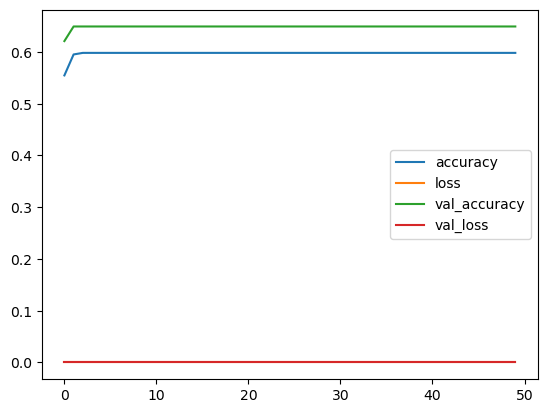

In [42]:
model_loss.plot()

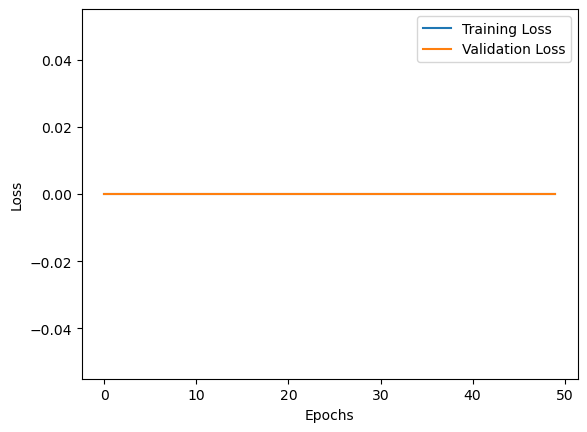

In [43]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.show()

In [44]:
sample = np.array([[6,148,72,35,0,33.6,0.627]])
sample = scaler.transform(sample)

model.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


array([[0.]], dtype=float32)

In [45]:
model.save('model.keras')

In [46]:
import pickle

In [47]:
filename='model.keras'
pickle.dump(model,open(filename,'wb'))

In [48]:
loaded_model=pickle.load(open('model.keras','rb'))

In [49]:
sample=np.array([[6,148,72,35,0,33.6,0.627]])
sample=scaler.transform(sample)

In [50]:
loaded_model.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


array([[0.]], dtype=float32)

In [51]:
import os
os.getcwd()

'C:\\Users\\Vennela\\Documents\\ANN_pregnancy'